In [70]:
import numpy as np
from scipy.stats import dirichlet
from scipy.spatial import Delaunay
import plotly.graph_objects as go
import numpy as np
from scipy.special import gammaln

def dirichlet_pdf(points, alpha):
    """
    Vectorized & numerically stable Dirichlet PDF
    """

    alpha = np.asarray(alpha)
    x = np.asarray(points)

    # log form (stabil!)
    log_norm = (
        np.sum(gammaln(alpha))
        - gammaln(np.sum(alpha))
    )

    log_pdf = (
        np.sum((alpha - 1) * np.log(x + 1e-12), axis=1)
        - log_norm
    )

    return np.exp(log_pdf)

def sample_simplex(n=2000):
    u = np.random.rand(n)
    v = np.random.rand(n)

    mask = u + v <= 1
    u, v = u[mask], v[mask]

    w = 1 - u - v
    return np.vstack([u, v, w]).T

def compute_pdf(points, alpha):
    return dirichlet_pdf(points, alpha)

def plot_dirichlet_surface(alpha, n=3000):

    pts = sample_simplex(n)
    pdf = compute_pdf(pts, alpha)

    u, v, w = pts[:,0], pts[:,1], pts[:,2]

    # 2D projection für triangulation
    xy = np.vstack([u, v]).T
    tri = Delaunay(xy)

    fig = go.Figure(data=[
        go.Mesh3d(
            x=u,
            y=v,
            z=w,
            intensity=pdf,
            colorscale="Viridis",
            opacity=1.0,
            i=tri.simplices[:,0],
            j=tri.simplices[:,1],
            k=tri.simplices[:,2]
        )
    ])

    fig.update_layout(
        title=f"Dirichlet Surface on Simplex α={alpha}",
        scene=dict(
            xaxis_title="S",
            yaxis_title="C",
            zaxis_title="U"
        )
    )

    fig.show()

def plot_dirichlet_3d(alpha, n=2000, scale=0.5):

    pts = sample_simplex(n)
    pdf = dirichlet_pdf(pts, alpha)

    u, v, w = pts[:,0], pts[:,1], pts[:,2]

    # baryzentrische 3D Struktur bleibt erhalten
    # → wir deformieren die Fläche entlang Normale (simple trick)

    # hier: künstliche Höhenachse = PDF
    z = w + scale * pdf   # <<<<<< DAS ist der 3D-Effekt

    xy = np.vstack([u, v]).T
    tri = Delaunay(xy)

    fig = go.Figure(data=[
        go.Mesh3d(
            x=u,
            y=v,
            z=z,
            intensity=pdf,
            colorscale="Viridis",
            opacity=1.0,
            i=tri.simplices[:,0],
            j=tri.simplices[:,1],
            k=tri.simplices[:,2]
        )
    ])

    fig.update_layout(
        title=f"Dirichlet PDF Deformed Simplex α={alpha}",
        scene=dict(
            xaxis_title="S",
            yaxis_title="C",
            zaxis_title="U + PDF deformation"
        )
    )

    fig.show()


In [71]:
plot_dirichlet_surface([3, 5, 2])
plot_dirichlet_3d([5, 3, 2])

In [38]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import dirichlet

def sample_simplex_grid(n=80):
    u_vals = []
    v_vals = []
    w_vals = []

    for i in range(n):
        for j in range(n):
            u = i / (n - 1)
            v = j / (n - 1)

            if u + v <= 1:
                w = 1 - u - v
                u_vals.append(u)
                v_vals.append(v)
                w_vals.append(w)

    return np.array(u_vals), np.array(v_vals), np.array(w_vals)

def dirichlet_pdf(alpha, points):
    return dirichlet.pdf(points, alpha)

import plotly.figure_factory as ff
from scipy.spatial import Delaunay

def plot_dirichlet_simplex(alpha, n=40):

    u, v, w = sample_simplex_grid(n)

    points = np.vstack([u, v, w]).T

    # Dirichlet PDF
    pdf = dirichlet_pdf_manual(points, alpha)

    # baryzentrisch → 2D projection für triangulation
    xy = np.vstack([u, v]).T
    tri = Delaunay(xy)

    fig = go.Figure(data=[
        go.Mesh3d(
            x=u,
            y=v,
            z=w,
            intensity=pdf,
            colorscale='Viridis',
            opacity=1.0,
            i=tri.simplices[:, 0],
            j=tri.simplices[:, 1],
            k=tri.simplices[:, 2]
        )
    ])

    fig.update_layout(
        title=f"Dirichlet PDF on Barycentric Simplex (α={alpha})",
        scene=dict(
            xaxis_title='S',
            yaxis_title='C',
            zaxis_title='U'
        )
    )

    fig.show()

import numpy as np
from scipy.special import gamma

def dirichlet_pdf_manual(points, alpha):
    a1, a2, a3 = alpha

    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    # Schutz: nur gültiger simplex
    mask = (x >= 0) & (y >= 0) & (z >= 0)

    out = np.zeros(len(points))

    B = (gamma(a1) * gamma(a2) * gamma(a3)) / gamma(a1 + a2 + a3)

    out[mask] = (
        (x[mask] ** (a1 - 1)) *
        (y[mask] ** (a2 - 1)) *
        (z[mask] ** (a3 - 1))
    ) / B

    return out



In [39]:
plot_dirichlet_simplex([10, 2, 2])   # stabil / support dominant
plot_dirichlet_simplex([2, 10, 2])   # conflict dominant
plot_dirichlet_simplex([2, 2, 10])   # uncertainty dominant
plot_dirichlet_simplex([1, 1, 1])    # maximal uninformativ

In [29]:
from scipy.stats import dirichlet
import numpy as np
from scipy.stats import chi2

def nis_to_evidence_3(nis, k):
    """
    Returns:
        S: support
        C: conflict
        U: uncertainty
    """

    # χ² likelihood (how plausible is this value)
    likelihood = chi2.pdf(nis, df=k)

    # normalize likelihood by maximum (at mode approx k-2)
    mode = max(k - 2, 0.1)
    max_likelihood = chi2.pdf(mode, df=k)
    support = likelihood / (max_likelihood + 1e-12)

    # tail probability = conflict indicator
    upper_tail = 1 - chi2.cdf(nis, df=k)
    lower_tail = chi2.cdf(nis, df=k)

    conflict = 2 * min(lower_tail, upper_tail)

    # uncertainty = inverse confidence
    uncertainty = np.exp(-abs(nis - k) / (2 * k))

    # normalize to simplex
    total = support + conflict + uncertainty + 1e-12

    return support/total, conflict/total, uncertainty/total

def evidence_to_dirichlet(S, C, U, scale=10):
    """
    Converts evidence to Dirichlet parameters.
    scale controls confidence strength.
    """

    alpha_S = 1 + scale * S
    alpha_C = 1 + scale * C
    alpha_U = 1 + scale * U

    return np.array([alpha_S, alpha_C, alpha_U])

def sample_dirichlet(alpha, n=5000):
    return dirichlet.rvs(alpha, size=n)

import plotly.graph_objects as go

def plot_dirichlet(alpha):
    samples = sample_dirichlet(alpha)

    S = samples[:, 0]
    C = samples[:, 1]
    U = samples[:, 2]

    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=S,
        y=C,
        z=U,
        mode='markers',
        marker=dict(size=2, opacity=0.5)
    ))

    fig.update_layout(
        scene=dict(
            xaxis_title='Support',
            yaxis_title='Conflict',
            zaxis_title='Uncertainty'
        ),
        title="Dirichlet Evidence Space (from NIS)"
    )

    fig.show()

def nis_to_dirichlet_pipeline(nis, k):
    S, C, U = nis_to_evidence_3(nis, k)
    alpha = evidence_to_dirichlet(S, C, U)
    return alpha



In [31]:
nis_values = [1.5, 2.0, 5.0, 10.0]  # k=2 Beispiel
k = 2

for nis in nis_values:
    alpha = nis_to_dirichlet_pipeline(nis, k)
    print("NIS:", nis, "Dirichlet α:", alpha)
    plot_dirichlet(alpha)


NIS: 1.5 Dirichlet α: [3.13693963 5.06543971 4.79762065]


NIS: 2.0 Dirichlet α: [2.82210149 4.4664731  5.71142542]


NIS: 5.0 Dirichlet α: [2.1938294  3.2712113  7.53495931]


NIS: 10.0 Dirichlet α: [1.45437171 1.86442348 9.68120482]


In [2]:
import matplotlib as mpl
import matplotlib.style

print("usetex:", mpl.rcParams["text.usetex"])

usetex: True


In [4]:
np.linspace(0,1,50)

array([0.        , 0.02040816, 0.04081633, 0.06122449, 0.08163265,
       0.10204082, 0.12244898, 0.14285714, 0.16326531, 0.18367347,
       0.20408163, 0.2244898 , 0.24489796, 0.26530612, 0.28571429,
       0.30612245, 0.32653061, 0.34693878, 0.36734694, 0.3877551 ,
       0.40816327, 0.42857143, 0.44897959, 0.46938776, 0.48979592,
       0.51020408, 0.53061224, 0.55102041, 0.57142857, 0.59183673,
       0.6122449 , 0.63265306, 0.65306122, 0.67346939, 0.69387755,
       0.71428571, 0.73469388, 0.75510204, 0.7755102 , 0.79591837,
       0.81632653, 0.83673469, 0.85714286, 0.87755102, 0.89795918,
       0.91836735, 0.93877551, 0.95918367, 0.97959184, 1.        ])

In [2]:
import subjective_logic as sl
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
plt.style.use('default')
import numpy as np
from subjective_logic.draw_sl_opinions import *
fig, ax = plt.subplots()
fig, ax = create_triangle_plot()
plt.show()
plt.figure()
alphas = [8, 50]
dist = sl.DirichletDistribution2f(alphas)
print(dist.evaluate)
x = np.linspace(0.001,0.999,500)
orig = list(map(dist.evaluate, x))
plt.plot(x, orig)

plt.show()


### Opinion + PDF Visualization

In [7]:
import numpy as np

def sample_truncated_gaussian_1d(sigma=1.0, truncation_sigma=1.0, n=10000, seed=42):
    rng = np.random.default_rng(seed)
    samples = []

    while len(samples) < n:
        x = rng.normal(loc=0.0, scale=sigma, size=n)
        x = x[np.abs(x) <= truncation_sigma * sigma]
        samples.extend(x.tolist())

    return np.array(samples[:n])

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('TkAgg')
from scipy.stats import norm

sigma = 1.0
truncation_sigma = 2.0
n = 10000

samples_trunc = sample_truncated_gaussian_1d(
    sigma=sigma,
    truncation_sigma=truncation_sigma,
    n=n,
    seed=42
)

samples_gauss = np.random.default_rng(123).normal(0.0, sigma, size=n)

x = np.linspace(-4*sigma, 4*sigma, 1000)

plt.figure(figsize=(8, 5))
plt.hist(samples_gauss, bins=100, density=True, alpha=0.35, label="Gaussian samples")
plt.hist(samples_trunc, bins=100, density=True, alpha=0.35, label="Truncated Gaussian samples")
plt.plot(x, norm.pdf(x, loc=0, scale=sigma), label="Gaussian PDF")
plt.axvline(-truncation_sigma*sigma, linestyle="--", label="Truncation boundary")
plt.axvline(truncation_sigma*sigma, linestyle="--")
plt.grid()
plt.legend()
plt.title("Gaussian vs. Truncated Gaussian")
plt.xlabel("x")
plt.ylabel("density")
plt.show()

In [6]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import numpy as np

sigma = 1.0
truncation_sigma = 1.0
n = 100000

samples_trunc = sample_truncated_gaussian_1d(
    sigma=sigma,
    truncation_sigma=truncation_sigma,
    n=n,
    seed=42
)

samples_gauss = np.random.default_rng(123).normal(0.0, sigma, size=n)

u_trunc = norm.cdf(samples_trunc / sigma)
u_gauss = norm.cdf(samples_gauss / sigma)

plt.figure(figsize=(8, 5))
plt.hist(u_gauss, bins=50, density=True, alpha=0.35, label="Gaussian -> PIT")
plt.hist(u_trunc, bins=50, density=True, alpha=0.35, label="Truncated Gaussian -> PIT")
plt.axvline(norm.cdf(-truncation_sigma), linestyle="--", label="Expected PIT gap boundary")
plt.axvline(norm.cdf(truncation_sigma), linestyle="--")
plt.grid()
plt.legend()
plt.title("PIT values")
plt.xlabel("u")
plt.ylabel("density")
plt.show()

In [5]:
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
plt.style.use('default')
import subjective_logic as sl
from subjective_logic.draw_sl_opinions import create_triangle_plot, reset_plot


import numpy as np
plt.ion()
# Beispiel Dirichlet
evidence = [0.8, 0.2]
dist = sl.DirichletDistribution2d.from_evidences(evidence)
op = dist.as_opinion()
# op.prior_belief_masses = [1.0, 0.0]
print(dist.as_opinion())
print(op.getBinomialProjection())
print(sum(op.as_dirichlet().evidences))
dist = op.as_dirichlet()

x = np.linspace(0.001, 0.999, 500)

y = list(map(dist.evaluate, x))

fig_dirichlet, ax_dirichlet = plt.subplots()  # neue Figur
ax_dirichlet.plot(x, y)
ax_dirichlet.set_title("Dirichlet Distribution")
# plt.show()  # zeigt Dirichlet-Plot in separatem Fenster


# Sicherstellen, dass triangle_vectors initialisiert wird
reset_plot()  # setzt ax, fig global auf None

fig_triangle, ax_triangle = create_triangle_plot()  # erstes Dreieck
sl.draw_point(dist.as_opinion())
# plt.ion()
plt.show()  # zeigt das Dreieck in einem eigenen Fenster

opinion: [bel: 0.266667; disbel: 0.066667; uncertainty: 0.666667] | prior: [bel: 0.500000; disbel: 0.500000]
0.6000000000000001
0.9999999999999999


Exception in Tkinter callback
Traceback (most recent call last):
  File "/usr/lib/python3.12/tkinter/__init__.py", line 1967, in __call__
    return self.func(*args)
           ^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/tkinter/__init__.py", line 861, in callit
    func(*args)
  File "/home/hillitzer/workspace/subjective_logic/venv/lib/python3.12/site-packages/matplotlib/backends/_backend_tk.py", line 302, in idle_draw
    self.draw()
  File "/home/hillitzer/workspace/subjective_logic/venv/lib/python3.12/site-packages/matplotlib/backends/backend_tkagg.py", line 10, in draw
    super().draw()
  File "/home/hillitzer/workspace/subjective_logic/venv/lib/python3.12/site-packages/matplotlib/backends/backend_agg.py", line 382, in draw
    self.figure.draw(self.renderer)
  File "/home/hillitzer/workspace/subjective_logic/venv/lib/python3.12/site-packages/matplotlib/artist.py", line 94, in draw_wrapper
    result = draw(artist, renderer, *args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^

In [23]:
import matplotlib
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
plt.style.use('default')
import subjective_logic as sl
from subjective_logic.draw_sl_opinions import create_triangle_plot, reset_plot


import numpy as np
plt.ion()
# Beispiel Dirichlet
alphas = [3, 0]
dist = sl.DirichletDistribution2d(alphas)
print(dist.as_opinion())
x = np.linspace(0.001, 0.999, 500)

y = list(map(dist.evaluate, x))

fig_dirichlet, ax_dirichlet = plt.subplots()  # neue Figur
ax_dirichlet.plot(x, y)
ax_dirichlet.set_title("Dirichlet Distribution")
# plt.show()  # zeigt Dirichlet-Plot in separatem Fenster


# Sicherstellen, dass triangle_vectors initialisiert wird
reset_plot()  # setzt ax, fig global auf None

fig_triangle, ax_triangle = create_triangle_plot()  # erstes Dreieck
sl.draw_point(dist.as_opinion())
# plt.ion()
plt.show()  # zeigt das Dreieck in einem eigenen Fenster
y

opinion: [bel: 0.666667; disbel: -0.333333; uncertainty: 0.666667] | prior: [bel: 0.500000; disbel: 0.500000]


[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0

In [10]:
op = dist.as_opinion()
op.prior_belief_masses = [1.0, 0]
op_proj = op.getProjection()
op.prior_belief_masses

[ 1.000000 0.000000]

In [14]:

def multinomial_opinion_to_binomial_ok_opinion(op, W, prior_ok=0.5, eps=1e-12):
    """
    Maps a W-dimensional multinomial opinion to a binomial OK opinion.

    H = "component/model is consistent"

    Returns:
        op_ok: binomial opinion with
            b = OK belief
            d = alarm / inconsistency disbelief
            u = original uncertainty
    """
    u = op.uncertainty()
    c = 1.0 - u

    if c <= eps:
        op_ok = sl.Opinion2d(0.0, 0.0)
        op_ok.prior_belief_masses = [prior_ok, 1.0 - prior_ok]
        return op_ok

    a = np.ones(W) / W
    b = np.asarray(op.belief_masses, dtype=float)

    # evidential distribution
    b_tilde = b / c

    # normalized TV distance
    tv = 0.5 * np.sum(np.abs(b_tilde - a))
    tv_max = 1.0 - 1.0 / W

    d_alarm = c * tv / tv_max
    d_alarm = np.clip(d_alarm, 0.0, c)

    b_ok = c - d_alarm

    op_ok = sl.Opinion2d(b_ok, d_alarm)
    op_ok.prior_belief_masses = [prior_ok, 1.0 - prior_ok]
    return op_ok

In [18]:
import subjective_logic as sl
import numpy as np
W = 5
op_ref = eval(f"sl.Opinion{W}d")(*([1/W]*W))
op = sl.DirichletDistribution5d().from_evidences([29, 23, 12, 12, 24])
op = op.as_opinion()
bin_op = multinomial_opinion_to_binomial_ok_opinion(op, W)
bin_op.getProjection()

[ 0.785714 0.214286]


=== Correlation demo ===
n=200, W=7, rho=0.99, MC=1000

p_ok_radial  | nom=0.905 [0.863, 0.940] | corr=0.768 [0.708, 0.826] | drop=0.137
p_ok_x       | nom=0.911 [0.870, 0.947] | corr=0.914 [0.870, 0.949] | drop=-0.003
p_ok_y       | nom=0.912 [0.873, 0.947] | corr=0.912 [0.870, 0.947] | drop=0.000
p_ok_comp    | nom=0.831 [0.781, 0.878] | corr=0.834 [0.767, 0.893] | drop=-0.003

Representative PIT counts, nominal:
radial: [715 730 741 685 734 681 714]
x:      [747 690 721 687 744 720 691]
y:      [702 709 734 713 718 740 684]

Representative PIT counts, correlated:
radial: [1541  661  516  512  486  497  787]
x:      [714 740 696 741 677 755 677]
y:      [720 730 712 695 743 728 672]


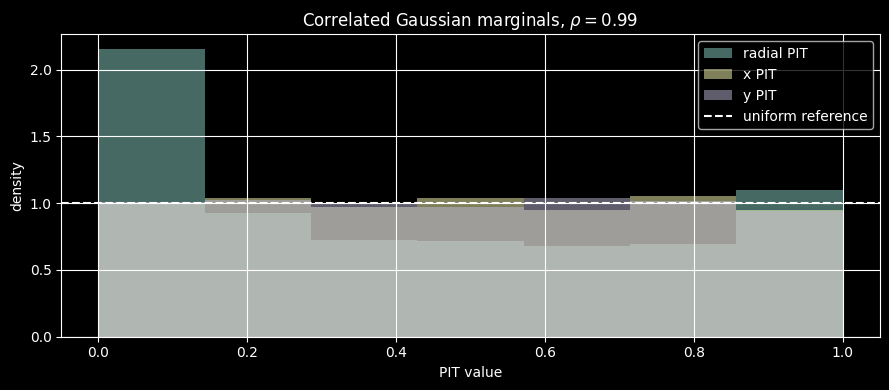

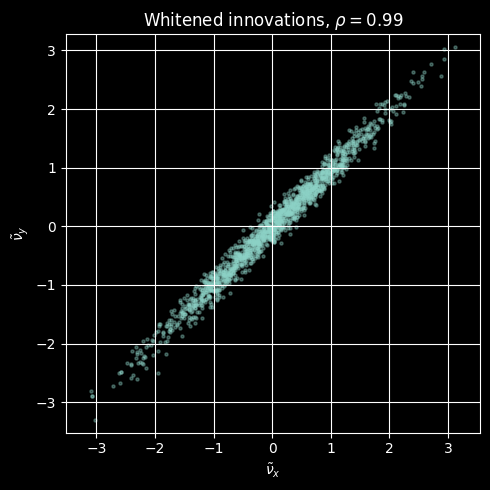

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2
import subjective_logic as sl


def multinomial_opinion_to_binomial_ok_opinion(op, W, prior_ok=0.5, eps=1e-12):
    """
    Same mapping as in your main script:
    W-dimensional uniformity opinion -> binomial OK opinion.

    Uses normalized total variation / L1 conflict:
        d_alarm = (1-u) * TV(b_tilde, uniform) / TV_max
        b_ok    = (1-u) - d_alarm
    """
    u = op.uncertainty()
    c = 1.0 - u

    if c <= eps:
        op_ok = sl.Opinion2d(0.0, 0.0)
        op_ok.prior_belief_masses = [prior_ok, 1.0 - prior_ok]
        return op_ok

    a = np.ones(W) / W
    b = np.asarray(op.belief_masses, dtype=float)

    b_tilde = b / c

    tv = 0.5 * np.sum(np.abs(b_tilde - a))
    tv_max = 1.0 - 1.0 / W

    d_alarm = c * tv / tv_max
    d_alarm = float(np.clip(d_alarm, 0.0, c))

    b_ok = c - d_alarm

    op_ok = sl.Opinion2d(b_ok, d_alarm)
    op_ok.prior_belief_masses = [prior_ok, 1.0 - prior_ok]
    return op_ok


def pit_values_to_multinomial_opinion(u_values, W):
    """
    Convert PIT values in [0,1] to a W-dimensional Dirichlet/multinomial opinion.
    """
    u_values = np.asarray(u_values, dtype=float)
    u_values = np.clip(u_values, 0.0, 1.0)

    bins = np.linspace(0.0, 1.0, W + 1)
    counts, _ = np.histogram(u_values, bins=bins)

    dist = eval(f"sl.DirichletDistribution{W}d").from_evidences(
        counts.astype(float)
    )
    return dist.as_opinion(), counts


def sample_nominal_whitened_innovations(n, rng):
    """
    Nominal case:
        x ~ N(0,1)
        y ~ N(0,1)
        independent
    """
    xy = rng.normal(size=(n, 2))
    return xy[:, 0], xy[:, 1]


def sample_correlated_whitened_innovations(n, rng, rho=0.99):
    """
    Correlated Gaussian case:
        x ~ N(0,1)
        y ~ N(0,1)
        corr(x,y)=rho

    Marginals are still nominal, but the radial chi-square assumption is violated.
    """
    cov = np.array([
        [1.0, rho],
        [rho, 1.0],
    ])

    xy = rng.multivariate_normal(
        mean=np.zeros(2),
        cov=cov,
        size=n,
    )

    return xy[:, 0], xy[:, 1]


def evaluate_window(x, y, W=7, prior_radial=0.5, prior_comp=np.sqrt(0.5)):
    """
    Compute radial, x, y, and combined-component binomial OK opinions
    from one window of whitened innovation samples.
    """
    # Component PITs
    u_x = norm.cdf(x)
    u_y = norm.cdf(y)

    # Radial PIT
    d2 = x**2 + y**2
    u_radial = chi2.cdf(d2, df=2)

    # Multinomial opinions over uniform PIT reference
    op_rad_m, counts_rad = pit_values_to_multinomial_opinion(u_radial, W)
    op_x_m, counts_x = pit_values_to_multinomial_opinion(u_x, W)
    op_y_m, counts_y = pit_values_to_multinomial_opinion(u_y, W)

    # Binomial OK opinions using your DC_norm mapping
    op_rad = multinomial_opinion_to_binomial_ok_opinion(
        op_rad_m,
        W=W,
        prior_ok=prior_radial,
    )

    op_x = multinomial_opinion_to_binomial_ok_opinion(
        op_x_m,
        W=W,
        prior_ok=prior_comp,
    )

    op_y = multinomial_opinion_to_binomial_ok_opinion(
        op_y_m,
        W=W,
        prior_ok=prior_comp,
    )

    # Combined component proposition:
    # H_comp = H_x AND H_y
    op_comp = op_x.multiply(op_y)

    result = {
        "p_ok_radial": op_rad.getProjection()[0],
        "p_ok_x": op_x.getProjection()[0],
        "p_ok_y": op_y.getProjection()[0],
        "p_ok_comp": op_comp.getProjection()[0],
        "u_radial": op_rad.uncertainty(),
        "u_x": op_x.uncertainty(),
        "u_y": op_y.uncertainty(),
        "u_comp": op_comp.uncertainty(),
        "counts_radial": counts_rad,
        "counts_x": counts_x,
        "counts_y": counts_y,
        "u_radial_values": u_radial,
        "u_x_values": u_x,
        "u_y_values": u_y,
    }

    return result


def run_correlation_demo(
    n=200,
    W=7,
    rho=0.99,
    n_mc=1000,
    seed=42,
    plot=True,
):
    rng = np.random.default_rng(seed)

    nominal_results = []
    correlated_results = []

    for _ in range(n_mc):
        x0, y0 = sample_nominal_whitened_innovations(n, rng)
        x1, y1 = sample_correlated_whitened_innovations(n, rng, rho=rho)

        nominal_results.append(evaluate_window(x0, y0, W=W))
        correlated_results.append(evaluate_window(x1, y1, W=W))

    def collect(results, key):
        return np.asarray([r[key] for r in results], dtype=float)

    summary = {}

    for key in ["p_ok_radial", "p_ok_x", "p_ok_y", "p_ok_comp"]:
        nominal = collect(nominal_results, key)
        corr = collect(correlated_results, key)

        summary[key] = {
            "nominal_mean": np.mean(nominal),
            "nominal_q05": np.quantile(nominal, 0.05),
            "nominal_q95": np.quantile(nominal, 0.95),
            "correlated_mean": np.mean(corr),
            "correlated_q05": np.quantile(corr, 0.05),
            "correlated_q95": np.quantile(corr, 0.95),
            "mean_drop": np.mean(nominal) - np.mean(corr),
        }

    print("\n=== Correlation demo ===")
    print(f"n={n}, W={W}, rho={rho}, MC={n_mc}")
    print()

    for key, vals in summary.items():
        print(
            f"{key:12s} | "
            f"nom={vals['nominal_mean']:.3f} "
            f"[{vals['nominal_q05']:.3f}, {vals['nominal_q95']:.3f}] | "
            f"corr={vals['correlated_mean']:.3f} "
            f"[{vals['correlated_q05']:.3f}, {vals['correlated_q95']:.3f}] | "
            f"drop={vals['mean_drop']:.3f}"
        )

    # One representative large sample for PIT histograms
    x0, y0 = sample_nominal_whitened_innovations(5000, rng)
    x1, y1 = sample_correlated_whitened_innovations(5000, rng, rho=rho)

    res0 = evaluate_window(x0, y0, W=W)
    res1 = evaluate_window(x1, y1, W=W)

    print("\nRepresentative PIT counts, nominal:")
    print("radial:", res0["counts_radial"])
    print("x:     ", res0["counts_x"])
    print("y:     ", res0["counts_y"])

    print("\nRepresentative PIT counts, correlated:")
    print("radial:", res1["counts_radial"])
    print("x:     ", res1["counts_x"])
    print("y:     ", res1["counts_y"])

    if plot:
        bins = np.linspace(0.0, 1.0, W + 1)

        plt.figure(figsize=(9, 4))
        plt.hist(
            res1["u_radial_values"],
            bins=bins,
            density=True,
            alpha=0.5,
            label="radial PIT",
        )
        plt.hist(
            res1["u_x_values"],
            bins=bins,
            density=True,
            alpha=0.5,
            label="x PIT",
        )
        plt.hist(
            res1["u_y_values"],
            bins=bins,
            density=True,
            alpha=0.5,
            label="y PIT",
        )
        plt.axhline(1.0, linestyle="--", label="uniform reference")
        plt.grid()
        plt.legend()
        plt.xlabel("PIT value")
        plt.ylabel("density")
        plt.title(rf"Correlated Gaussian marginals, $\rho={rho}$")
        plt.tight_layout()

        plt.figure(figsize=(5, 5))
        plt.scatter(x1[:1500], y1[:1500], s=5, alpha=0.35)
        plt.axis("equal")
        plt.grid()
        plt.xlabel(r"$\tilde{\nu}_x$")
        plt.ylabel(r"$\tilde{\nu}_y$")
        plt.title(rf"Whitened innovations, $\rho={rho}$")
        plt.tight_layout()

        plt.show()

    return summary


if __name__ == "__main__":
    run_correlation_demo(
        n=200,
        W=7,
        rho=0.99,
        n_mc=1000,
        seed=42,
        plot=True,
    )

In [44]:
import subjective_logic as sl
import numpy as np
u = 0.2
op2 = sl.Opinion2d(1 - u - 0.4, 0.4)
print(op2)
print(op2.belief_masses)
print(op2.getProjection())

ent = -1 * np.sum(op2.getProjection() * np.log2(op2.belief_masses))
print(ent / np.log2(7))

opinion: [bel: 0.400000; disbel: 0.400000; uncertainty: 0.200000] | prior: [bel: 0.500000; disbel: 0.500000]
[ 0.400000 0.400000]
[ 0.500000 0.500000]
0.4708802882388939


In [6]:
import subjective_logic as sl
import numpy as np
op2 = sl.Opinion7d(0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1)
print(op2)
print(op2.belief_masses)
print(op2.getProjection())

ent = -1 * np.sum(op2.getProjection() * np.log2(op2.belief_masses))
print(ent / np.log2(7))

opinion: [bel masses: 0.100000, 0.100000, 0.100000, 0.100000, 0.100000, 0.100000, 0.100000, uncertainty: 0.300000] | prior: [bel masses: 0.142857, 0.142857, 0.142857, 0.142857, 0.142857, 0.142857, 0.142857, ]
[ 0.100000 0.100000 0.100000 0.100000 0.100000 0.100000 0.100000]
[ 0.142857 0.142857 0.142857 0.142857 0.142857 0.142857 0.142857]
1.1832946624549383


In [56]:
import subjective_logic as sl
import numpy as np
W = 7
radial_window_op = eval(f"sl.Opinion{W}d")(list(np.zeros(W)))
radial_window_op

opinion: [bel masses: 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, uncertainty: 1.000000] | prior: [bel masses: 0.142857, 0.142857, 0.142857, 0.142857, 0.142857, 0.142857, 0.142857, ]

In [88]:
import numpy as np

def calibrate_entropy_threshold(W, n_s, alpha=0.05, N=100000, rng=None):
    n_s = int(round(n_s))
    if n_s <= 0:
        raise ValueError("n_s must be positive.")
    if not (0 < alpha < 1):
        raise ValueError("alpha must be in (0,1).")

    rng = np.random.default_rng(rng)
    vals = np.empty(N, dtype=float)
    p0 = np.full(W, 1.0 / W)

    for k in range(N):
        counts = rng.multinomial(n_s, p0)
        p = counts / n_s

        nz = p > 0
        H = -np.sum(p[nz] * np.log2(p[nz]))
        H /= np.log2(W)
        vals[k] = 1.0 - H

    return float(np.quantile(vals, 1.0 - alpha))

calibrate_entropy_threshold(7, 35, alpha=0.01)

0.1313954903877489

In [85]:
import numpy as np
def calibrate_entropy_threshold(W, n_s, alpha=0.05, N=100000):
    vals = []
    for _ in range(N):
        # sample uniform multinomial
        counts = np.random.multinomial(n_s, [1/W]*W)
        p = counts / np.sum(counts)

        H = -np.sum(p * np.log2(p + 1e-15))
        H /= np.log2(W)
        E = 1 - H

        vals.append(E)
    # print(counts)
    # print(np.mean(vals))
    # print(np.std(vals))
    # print(np.min(vals))
    # print(np.max(vals))
    return np.quantile(vals, 1 - alpha)

calibrate_entropy_threshold(6, 36, alpha=0.01)

np.float64(0.12423048621428201)

In [52]:
def calibrate_projected_ok_threshold(
    W,
    n_s,
    alpha=0.01,
    N=100000,
    prior_ok=0.5,
    seed=None,
):
    """
    Gibt lower threshold für P_OK zurück:
        reject / alarm if P_OK < tau_ok

    tau_ok ist das alpha-Quantil unter H0.
    """
    rng = np.random.default_rng(seed)
    vals = []

    a = np.ones(W) / W
    tv_max = 1.0 - 1.0 / W

    for _ in range(N):
        counts = rng.multinomial(n_s, a)

        R = np.sum(counts)
        u = W / (W + R)
        c = 1.0 - u

        b_tilde = counts / R

        tv = 0.5 * np.sum(np.abs(b_tilde - a))
        d = c * tv / tv_max
        d = np.clip(d, 0.0, c)

        b = c - d

        p_ok = b + prior_ok * u
        vals.append(p_ok)

    return np.quantile(vals, alpha)
calibrate_projected_ok_threshold(7, 35, alpha=0.01)

np.float64(0.638888888888889)

In [55]:
import numpy as np

def projected_ok_from_counts(
    counts,
    prior_ok=0.5,
):
    """
    Kalibriert dieselbe Größe wie deine binomiale Meta-Opinion:

        H = "system is OK"

        d = normalized L1 conflict
        b = 1 - u - d
        P_OK = b + prior_ok * u

    Die Counts werden als Evidenz einer W-dimensionalen multinomialen Opinion
    interpretiert.
    """
    counts = np.asarray(counts, dtype=float)
    W = len(counts)
    R = np.sum(counts)

    if R <= 0:
        # Keine Evidenz: b=d=0, u=1
        return prior_ok

    # Multinomial SL uncertainty
    u = W / (W + R)
    c = 1.0 - u

    # Das ist äquivalent zu b_tilde = b / (1-u)
    b_tilde = counts / R

    # Uniform reference/base rate
    a = np.ones(W) / W

    # Normalized TV distance
    tv = 0.5 * np.sum(np.abs(b_tilde - a))
    tv_max = 1.0 - 1.0 / W

    d = c * tv / tv_max
    d = np.clip(d, 0.0, c)

    b = c - d

    p_ok = b + prior_ok * u

    return p_ok

def calibrate_projected_ok_threshold(
    W,
    n_s,
    alpha=0.01,
    N=100000,
    prior_ok=0.5,
    seed=None,
):
    """
    Kalibriert den lower threshold für P_OK unter H0.

    H0:
        counts ~ Multinomial(n_s, uniform)

    Entscheidung:
        alarm, wenn P_OK < threshold

    Daher nehmen wir das alpha-Quantil.
    """
    rng = np.random.default_rng(seed)
    vals = []

    probs = np.ones(W) / W

    for _ in range(N):
        counts = rng.multinomial(n_s, probs)
        p_ok = projected_ok_from_counts(
            counts,
            prior_ok=prior_ok,
        )
        vals.append(p_ok)

    return np.quantile(vals, alpha)

tau_ok = calibrate_projected_ok_threshold(
    W=7,
    n_s=35,
    alpha=0.005,
    N=100000,
    prior_ok=0.995,
    seed=42,
)

print(tau_ok)

0.6936111111111112


In [78]:


th = dict()
for i in range(1, 151):
    th[f"7, {i}, 0.01"] = calibrate_entropy_threshold(7, i, alpha=0.01)



In [60]:
th_op = dict()
for i in range(1, 151):
    th_op[f"3, {i}, 0.005"] = calibrate_opinion_threshold(3, i, alpha=0.005, N=100_000)

[0 0 1]
[0 2 0]
[1 2 0]
[2 1 1]
[1 1 3]
[0 5 1]
[2 1 4]
[2 4 2]
[6 1 2]
[2 5 3]
[5 1 5]
[3 3 6]
[4 6 3]
[3 6 5]
[5 5 5]
[7 4 5]
[1 9 7]
[7 8 3]
[9 5 5]
[7 7 6]
[8 8 5]
[10  6  6]
[ 8  4 11]
[ 6 11  7]
[ 5  6 14]
[10 10  6]
[11  5 11]
[ 7 15  6]
[11  5 13]
[12 11  7]
[ 7 14 10]
[10 11 11]
[10 14  9]
[ 8 16 10]
[12  8 15]
[ 9 13 14]
[10 10 17]
[17 13  8]
[11 14 14]
[13 13 14]
[14 12 15]
[14 18 10]
[18  9 16]
[24 12  8]
[17 14 14]
[12 20 14]
[16 17 14]
[13 21 14]
[15 20 14]
[23 13 14]
[23 11 17]
[15 19 18]
[21 10 22]
[17 15 22]
[15 27 13]
[24 19 13]
[25 14 18]
[19 25 14]
[20 14 25]
[21 18 21]
[18 21 22]
[29 17 16]
[25 15 23]
[22 24 18]
[22 25 18]
[24 24 18]
[15 30 22]
[23 18 27]
[27 17 25]
[32 24 14]
[25 29 17]
[28 23 21]
[21 25 27]
[24 28 22]
[32 24 19]
[20 30 26]
[24 32 21]
[24 29 25]
[29 25 25]
[24 27 29]
[36 22 23]
[30 28 24]
[30 29 24]
[35 25 24]
[32 32 21]
[26 30 30]
[28 30 29]
[26 35 27]
[28 28 33]
[30 33 27]
[26 32 33]
[38 32 22]
[39 23 31]
[30 34 30]
[41 29 25]
[32 32 32]
[26 28 

In [22]:
th_adj_op = dict()
W = 7
alpha = 0.01
for i in range(1, 151):
    th_adj_op[f"{W}, {i}, {alpha}"] = calibrate_adjusted_dc_threshold(W, i, alpha=alpha, N=100_000)

In [79]:
import json
with open("entropy_threshold.json", "w") as f:
    json.dump(th, f)

In [96]:
import json
with open("opinion_threshold.json", "w") as f:
    json.dump(th_op, f)

In [12]:
import json
with open("adjusted_opinion_threshold.json", "w") as f:
    json.dump(th_adj_op, f)

In [30]:
import json
with open("adjusted_opinion_threshold.json", "r") as f:
    th_adj_op = json.load(f)

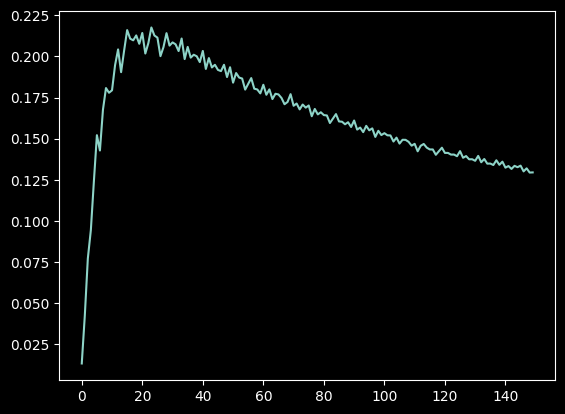

In [2]:
import json
with open("opinion_threshold.json", "r") as f:
    th_op = json.load(f)
import matplotlib.pyplot as plt
plt.figure()
plt.plot([float(th_op[f"7, {i}, 0.01"]) for i in range(1, 151)], label="opinion threshold")
plt.show()

In [103]:
[th_op[f"7, {i}, 0.01"] for i in range(1, 151)]

[np.float64(0.013392857142857146),
 np.float64(0.042328042328042326),
 np.float64(0.07714285714285717),
 np.float64(0.09445100354191263),
 np.float64(0.12400793650793646),
 np.float64(0.15215553677092136),
 np.float64(0.14285714285714285),
 np.float64(0.1676190476190476),
 np.float64(0.1808035714285714),
 np.float64(0.17795353435491845),
 np.float64(0.1794532627865961),
 np.float64(0.19469726948951321),
 np.float64(0.20428571428571435),
 np.float64(0.1904761904761905),
 np.float64(0.2036599763872491),
 np.float64(0.21604104779908173),
 np.float64(0.210813492063492),
 np.float64(0.20982857142857142),
 np.float64(0.2128064243448859),
 np.float64(0.20772094846168912),
 np.float64(0.21428571428571422),
 np.float64(0.20180057754374045),
 np.float64(0.20809523809523808),
 np.float64(0.2176304444774787),
 np.float64(0.2127511160714285),
 np.float64(0.21146530237439323),
 np.float64(0.20019772614928324),
 np.float64(0.20571428571428568),
 np.float64(0.21417548500881825),
 np.float64(0.20661588

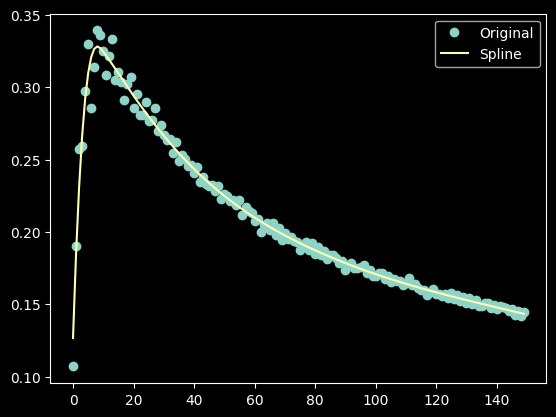

[(0, np.float64(0.1268002762185363)), (1, np.float64(0.18475173624370753)), (2, np.float64(0.23069473809306412)), (3, np.float64(0.2659516333545514)), (4, np.float64(0.29184477361611466)), (5, np.float64(0.3096965104656992)), (6, np.float64(0.32082919549125066)), (7, np.float64(0.32656518028071413)), (8, np.float64(0.328226816422035)), (9, np.float64(0.3271364555031588)), (10, np.float64(0.32461644911203064)), (11, np.float64(0.3217716556851088)), (12, np.float64(0.31883696105290166)), (13, np.float64(0.3158297578944305)), (14, np.float64(0.31276743888871655)), (15, np.float64(0.30966739671478083)), (16, np.float64(0.3065470240516448)), (17, np.float64(0.3034237135783295)), (18, np.float64(0.30031485797385626)), (19, np.float64(0.2972378499172461)), (20, np.float64(0.294207149988284)), (21, np.float64(0.2912254903698087)), (22, np.float64(0.28829267114542273)), (23, np.float64(0.28540849239872845)), (24, np.float64(0.2825727542133283)), (25, np.float64(0.27978525667282467)), (26, np.fl

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
alpha = 0.005
y = np.array([th_adj_op[f"{W}, {i}, {alpha}"] for i in range(1, 151)])  # deine Werte
x = np.arange(len(y))

# Spline fitten (s = Glättungsparameter!)
spline = UnivariateSpline(x, y, s=0.005)

# feinere x-Werte für glatte Kurve
x_smooth = np.linspace(x.min(), x.max(), len(y))
y_smooth = spline(x_smooth)

# Plot
plt.plot(x, y, 'o', label='Original')
plt.plot(x_smooth, y_smooth, '-', label='Spline')
plt.legend()
plt.show()
print(list(enumerate(y_smooth)))

In [19]:
np.argmax(y_smooth)

np.int64(8)

In [33]:
th_op_smoothed = dict()
for i in range(1, 151):
    th_op_smoothed[f"{W}, {i}, {alpha}"] = y_smooth[i-1]
th_op_smoothed

{'7, 1, 0.005': np.float64(0.1268002762185363),
 '7, 2, 0.005': np.float64(0.18475173624370753),
 '7, 3, 0.005': np.float64(0.23069473809306412),
 '7, 4, 0.005': np.float64(0.2659516333545514),
 '7, 5, 0.005': np.float64(0.29184477361611466),
 '7, 6, 0.005': np.float64(0.3096965104656992),
 '7, 7, 0.005': np.float64(0.32082919549125066),
 '7, 8, 0.005': np.float64(0.32656518028071413),
 '7, 9, 0.005': np.float64(0.328226816422035),
 '7, 10, 0.005': np.float64(0.3271364555031588),
 '7, 11, 0.005': np.float64(0.32461644911203064),
 '7, 12, 0.005': np.float64(0.3217716556851088),
 '7, 13, 0.005': np.float64(0.31883696105290166),
 '7, 14, 0.005': np.float64(0.3158297578944305),
 '7, 15, 0.005': np.float64(0.31276743888871655),
 '7, 16, 0.005': np.float64(0.30966739671478083),
 '7, 17, 0.005': np.float64(0.3065470240516448),
 '7, 18, 0.005': np.float64(0.3034237135783295),
 '7, 19, 0.005': np.float64(0.30031485797385626),
 '7, 20, 0.005': np.float64(0.2972378499172461),
 '7, 21, 0.005': np.

In [34]:
import json
with open("adjusted_opinion_threshold_smoothed.json", "r") as f:
    json_smoothed = json.load(f)

In [66]:
import json
with open("opinion_threshold_smoothed.json", "r") as f:
    json_smoothed = json.load(f)

In [36]:
th_op_smoothed

{'7, 1, 0.005': np.float64(0.1268002762185363),
 '7, 2, 0.005': np.float64(0.18475173624370753),
 '7, 3, 0.005': np.float64(0.23069473809306412),
 '7, 4, 0.005': np.float64(0.2659516333545514),
 '7, 5, 0.005': np.float64(0.29184477361611466),
 '7, 6, 0.005': np.float64(0.3096965104656992),
 '7, 7, 0.005': np.float64(0.32082919549125066),
 '7, 8, 0.005': np.float64(0.32656518028071413),
 '7, 9, 0.005': np.float64(0.328226816422035),
 '7, 10, 0.005': np.float64(0.3271364555031588),
 '7, 11, 0.005': np.float64(0.32461644911203064),
 '7, 12, 0.005': np.float64(0.3217716556851088),
 '7, 13, 0.005': np.float64(0.31883696105290166),
 '7, 14, 0.005': np.float64(0.3158297578944305),
 '7, 15, 0.005': np.float64(0.31276743888871655),
 '7, 16, 0.005': np.float64(0.30966739671478083),
 '7, 17, 0.005': np.float64(0.3065470240516448),
 '7, 18, 0.005': np.float64(0.3034237135783295),
 '7, 19, 0.005': np.float64(0.30031485797385626),
 '7, 20, 0.005': np.float64(0.2972378499172461),
 '7, 21, 0.005': np.

In [37]:
for k, v in th_op_smoothed.items():
    json_smoothed[k] = v

In [38]:
json_smoothed.keys()

dict_keys(['7, 1, 0.01', '7, 2, 0.01', '7, 3, 0.01', '7, 4, 0.01', '7, 5, 0.01', '7, 6, 0.01', '7, 7, 0.01', '7, 8, 0.01', '7, 9, 0.01', '7, 10, 0.01', '7, 11, 0.01', '7, 12, 0.01', '7, 13, 0.01', '7, 14, 0.01', '7, 15, 0.01', '7, 16, 0.01', '7, 17, 0.01', '7, 18, 0.01', '7, 19, 0.01', '7, 20, 0.01', '7, 21, 0.01', '7, 22, 0.01', '7, 23, 0.01', '7, 24, 0.01', '7, 25, 0.01', '7, 26, 0.01', '7, 27, 0.01', '7, 28, 0.01', '7, 29, 0.01', '7, 30, 0.01', '7, 31, 0.01', '7, 32, 0.01', '7, 33, 0.01', '7, 34, 0.01', '7, 35, 0.01', '7, 36, 0.01', '7, 37, 0.01', '7, 38, 0.01', '7, 39, 0.01', '7, 40, 0.01', '7, 41, 0.01', '7, 42, 0.01', '7, 43, 0.01', '7, 44, 0.01', '7, 45, 0.01', '7, 46, 0.01', '7, 47, 0.01', '7, 48, 0.01', '7, 49, 0.01', '7, 50, 0.01', '7, 51, 0.01', '7, 52, 0.01', '7, 53, 0.01', '7, 54, 0.01', '7, 55, 0.01', '7, 56, 0.01', '7, 57, 0.01', '7, 58, 0.01', '7, 59, 0.01', '7, 60, 0.01', '7, 61, 0.01', '7, 62, 0.01', '7, 63, 0.01', '7, 64, 0.01', '7, 65, 0.01', '7, 66, 0.01', '7, 67, 

In [39]:
with open("adjusted_opinion_threshold_smoothed.json", "w") as f:
    json.dump(json_smoothed, f)

In [68]:
with open("opinion_threshold_smoothed.json", "w") as f:
    json.dump(json_smoothed, f)

In [51]:
import numpy as np
def calibrate_entropy_exp_threshold(W, n_s, alpha=0.05, N=100000):
    vals = []
    for _ in range(N):
        # sample uniform multinomial
        counts = np.random.multinomial(n_s, [1/W]*W)
        p = counts / np.sum(counts)

        H = -np.sum(p * np.log(p + 1e-15))
        H /= np.log(W)
        E = 1 - H

        vals.append(E)
    # print(counts)
    # print(np.mean(vals))
    # print(np.std(vals))
    # print(np.min(vals))
    # print(np.max(vals))
    return np.quantile(vals, 1 - alpha)

calibrate_entropy_exp_threshold(6, 36, alpha=0.01)

np.float64(0.12423048621428201)

In [8]:
import numpy as np
import subjective_logic as sl
def calibrate_opinion_threshold(W, n_s, alpha=0.05, N=100000):
    vals = []
    op_ref = eval(f"sl.Opinion{W}d")(*([1/W]*W))
    for _ in range(N):
        # sample uniform multinomial
        counts = np.random.multinomial(n_s, [1/W]*W)
        dist = eval(f"sl.DirichletDistribution{W}d").from_evidences(counts)
        op = dist.as_opinion()
        dc = op.degree_of_conflict(op_ref)

        vals.append(dc)
    print(counts)
    # print(np.mean(vals))
    # print(np.std(vals))
    # print(np.min(vals))
    # print(np.max(vals))
    return np.quantile(vals, 1 - alpha)

def calculate_lt_evidence(W: int, alpha=0.99):
    return int((-(W - 1) + np.sqrt((W-1)**2 + ((4 * W) / (1 - alpha)))) / (2))


calibrate_opinion_threshold(5, 35, alpha=0.01)

[12  8  6  5  4]


np.float64(0.19687500000000002)

In [9]:
def calculate_lt_evidence(W: int, alpha=0.99):
    return int((-(W - 1) + np.sqrt((W-1)**2 + ((4 * W) / (1 - alpha)))) / (2))

calculate_lt_evidence(7, 0.99)

23

In [3]:
def calculate_alpha_from_lt_evidence(W: int, R: float):
    return 1 - W / (R * (R + W - 1))

calculate_alpha_from_lt_evidence(7, 80)

0.9989825581395348

In [65]:
import subjective_logic as sl
import numpy as np
def calibrate_adjusted_dc_threshold(W, n_s, alpha=0.005, N=100000):
    vals = []
    op_ref = eval(f"sl.Opinion{W}d")(*([1/W]*W))

    for _ in range(N):
        counts = np.random.multinomial(n_s, [1/W] * W)
        dist = eval(f"sl.DirichletDistribution{W}d").from_evidences(counts)
        op = dist.as_opinion()

        dc = op.degree_of_conflict(op_ref)
        c = 1.0 - op.uncertainty()

        vals.append(dc / c if c > 1e-9 else 0.0)

    return np.quantile(vals, 1 - alpha)

calibrate_adjusted_dc_threshold(7, 35, alpha=0.01)

np.float64(0.23809523809523803)

In [89]:
import subjective_logic as sl
def scalar_u_to_opinion(u: float, W: int, scale=1):
    """
    Map a scalar u in [0,1] to a W-dimensional one-hot evidence opinion.
    """
    if u == -1:
        return eval(f"sl.Opinion{W}d")(*([0]*W))

    u = float(np.clip(u, 0.0, 1.0))
    evidence = np.zeros(W, dtype=float)

    # Bin index in {0, ..., W-1}
    idx = min(int(np.floor(u * W)), W - 1)
    evidence[idx] = 1.0 * scale

    dist = eval(f"sl.DirichletDistribution{W}d").from_evidences(evidence)
    return dist.as_opinion()
def calibrate_q_like_ltst_threshold(
    W,
    short_window_size,
    discount,
    alpha=0.005,
    N_runs=2000,
    seq_len=None,
    fusion_type=sl.FusionType.AVERAGE,
    handle_st_conflict=False,
    avg_dc_conflict_handling=False,
    random_seed=12345,
):
    """
    Calibrate a channel-specific DC threshold for the Q-like opinion channel
    by simulating the complete LTST pipeline under H0:

        p_k ~ U(0,1)
          -> scalar_u_to_opinion(p_k, W)
          -> LTST with AVERAGE fusion
          -> DC to uniform reference opinion

    We collect all resulting DC values over all simulated sequences and return
    the (1-alpha)-quantile.

    Parameters
    ----------
    W : int
        Number of bins / opinion dimension.
    short_window_size : int
        LTST short window size.
    discount : float
        LTST discount.
    alpha : float
        Tail probability for threshold calibration.
    N_runs : int
        Number of Monte-Carlo runs.
    seq_len : int or None
        Length of each simulated p-value sequence.
        If None, use 4 * short_window_size.
    fusion_type : sl.FusionType
        LTST fusion type, should match the Q-channel LTST.
    handle_st_conflict : bool
        LTST config.
    avg_dc_conflict_handling : bool
        LTST config.
    random_seed : int
        RNG seed for reproducibility.

    Returns
    -------
    threshold : float
        Empirical (1-alpha)-quantile of the DC values under H0.
    dc_samples : ndarray
        All simulated DC values (can be useful for diagnostics).
    """
    rng = np.random.default_rng(random_seed)

    if seq_len is None:
        seq_len = 4 * short_window_size

    op_ref = eval(f"sl.Opinion{W}d")(*([1 / W] * W))
    dc_vals = []

    for _ in range(N_runs):
        ltst_q_mc = eval(f"sl.LongShortTermMemory{W}d")(
            short_window_size,
            1.0,   # dummy threshold, irrelevant for DC calibration itself
            discount,
            fusion_type,
            handle_st_conflict,
            avg_dc_conflict_handling
        )

        p_seq = rng.uniform(0.0, 1.0, size=seq_len)

        for p in p_seq:
            op = scalar_u_to_opinion(float(p), W)
            ltst_q_mc.add(op)
            op_buf = ltst_q_mc.get_opinion()
            dc_vals.append(op_buf.degree_of_conflict(op_ref))

    dc_vals = np.asarray(dc_vals, dtype=float)
    threshold = float(np.quantile(dc_vals, 1.0 - alpha))
    return threshold, dc_vals

THRESHOLD_Q, dc_q_cal_samples = calibrate_q_like_ltst_threshold(
    W=7,
    short_window_size=35,
    discount=0.99,
    alpha=0.005,
    N_runs=100_000,
    seq_len=35,
    fusion_type=sl.FusionType.AVERAGE,
    handle_st_conflict=False,
    avg_dc_conflict_handling=False,
    random_seed=12345,
)
print("Threshold for LTST Q-like:", THRESHOLD_Q)

Threshold for LTST Q-like: 0.013392857142857146


In [57]:
from scipy.stats import t

In [94]:
import numpy as np
from scipy.stats import chi2


def chisquare_uniform_test(counts, alpha=0.05):
    """
    Pearson chi-square goodness-of-fit test against the uniform distribution.

    Parameters
    ----------
    counts : array-like
        Observed category counts [N1, ..., NW].
    alpha : float
        Significance level, e.g. 0.05 or 0.01.

    Returns
    -------
    result : dict
        {
            "statistic": X2,
            "df": W - 1,
            "critical_value": tau_alpha,
            "p_value": p,
            "reject_H0": bool
        }
    """
    counts = np.asarray(counts, dtype=float)

    if counts.ndim != 1:
        raise ValueError("counts must be a 1D array.")
    if np.any(counts < 0):
        raise ValueError("counts must be nonnegative.")
    if not np.allclose(counts, np.round(counts)):
        raise ValueError("counts should be integer-valued frequencies.")
    if not (0 < alpha < 1):
        raise ValueError("alpha must be in (0,1).")

    n_s = counts.sum()
    W = len(counts)

    if W < 2:
        raise ValueError("Need at least 2 categories.")
    if n_s <= 0:
        raise ValueError("Total sample size must be positive.")

    expected = np.full(W, n_s / W)

    # Pearson chi-square statistic
    X2 = np.sum((counts - expected) ** 2 / expected)

    df = W - 1
    critical_value = chi2.ppf(1.0 - alpha, df=df)
    p_value = 1.0 - chi2.cdf(X2, df=df)

    return {
        "statistic": float(X2),
        "df": int(df),
        "critical_value": float(critical_value),
        "p_value": float(p_value),
        "reject_H0": bool(X2 > critical_value),
    }

chisquare_uniform_test([1, 1, 1, 1, 1, 1, 1], 0.01)

{'statistic': 30.374999999999996,
 'df': 6,
 'critical_value': 16.811893829770927,
 'p_value': 3.335311177488087e-05,
 'reject_H0': True}

In [70]:
def calculate_lt_evidence(W: int, alpha=0.99):
    return int((-(W - 1) + np.sqrt((W-1)**2 + ((4 * W) / (1 - alpha)))) / (2))

calculate_lt_evidence(7, 0.999)

80

In [42]:
W = 5
op_ref = eval(f"sl.Opinion{W}d")(*([1/W]*W))
op_ref

opinion: [bel masses: 0.200000, 0.200000, 0.200000, 0.200000, 0.200000, uncertainty: 0.000000] | prior: [bel masses: 0.200000, 0.200000, 0.200000, 0.200000, 0.200000, ]

In [58]:
W = 5
op_ref = eval(f"sl.Opinion{W}d")(*([0]*W))
op_ref

opinion: [bel masses: 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, uncertainty: 1.000000] | prior: [bel masses: 0.200000, 0.200000, 0.200000, 0.200000, 0.200000, ]

In [2]:
import subjective_logic as sl
# op_ref = sl.Opinion4d([0.25, 0.25, 0.25, 0.25])
op_ref = sl.Opinion4d([0.1, 0.1, 0.1, 0.1])
op_ref
op_ref.as_dirichlet().evidences

[ -nan 0.666667 0.000000 1394075764254713984706055050597532893540620035363824678777886684584228937402362309093762628850159277827899433451895832766063031364415636023088987624707225264209264640.000000]

In [2]:
import subjective_logic as sl
op = sl.Opinion(0, 0)
op

opinion: [bel: 0.000000; disbel: 0.000000; uncertainty: 1.000000] | prior: [bel: 0.500000; disbel: 0.500000]

In [12]:
import subjective_logic as sl
dist1 = sl.Opinion([1/3, 2/9, 1/9], [1/3, 1/3, 1/3])
dist2 = sl.Opinion([0, 0, 1/4], [1/3, 1/3, 1/3])
print(dist1)
print(dist2)
print(dist1.wb_fuse(dist2))
fusion = sl.Fusion.fuse_opinions(sl.FusionType.CUMULATIVE, dist1, dist2)
fusion

opinion: [bel masses: 0.333333, 0.222222, 0.111111, uncertainty: 0.333333] | prior: [bel masses: 0.333333, 0.333333, 0.333333, ]
opinion: [bel masses: 0.000000, 0.000000, 0.250000, uncertainty: 0.750000] | prior: [bel masses: 0.333333, 0.333333, 0.333333, ]
opinion: [bel masses: 0.285714, 0.190476, 0.130952, uncertainty: 0.392857] | prior: [bel masses: 0.333333, 0.333333, 0.333333, ]


opinion: [bel masses: 0.300000, 0.200000, 0.200000, uncertainty: 0.300000] | prior: [bel masses: 0.333333, 0.333333, 0.333333, ]

In [19]:
import plotly.graph_objects as go

fig_tri = go.Figure()

# Example
b, d, u = 0.3, 0.4, 0.3  # belief, disbelief, uncertainty
fig_tri.add_trace(go.Scatterternary({
    'a':[u],
    'b':[d],
    'c':[b],
    'mode':'markers+text',
    'text':['ω_X'],
    'textposition':'top center'
}))

fig_tri.update_layout({
    'ternary': {
        'sum': 1,
        'aaxis_title':'uncertainty',
        'baxis_title':'disbelief',
        'caxis_title':'belief'
    },
    'title':'Opinion Triangle'
})

fig_tri.show()

In [15]:
import numpy as np
import plotly.graph_objects as go
from scipy.stats import beta  # Beispiel: Beta als 2D-Dirichlet

x = np.linspace(0.001,0.999,500)
y = beta.pdf(x, 2, 0)  # ersetze mit dist.evaluate

fig_dir = go.Figure()
fig_dir.add_trace(go.Scatter(x=x, y=y, mode='lines', name='Dirichlet'))
fig_dir.update_layout(title='Dirichlet Distribution')
fig_dir.show()

In [4]:
import numpy as np
from scipy.stats import chi2

k = 2  # Freiheitsgrade
d2 = 5.0  # Mahalanobis-Distanz

# Wahrscheinlichkeit, dass eine Beobachtung weiter als d2 ist
p_value = 1 - chi2.cdf(d2, df=k)
print("p-value:", p_value)

p-value: 0.08208499862389884


### Animated Plot with Opinion and Beta-PDF

In [16]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import beta
import subjective_logic as sl

# -------------------------------
# Simulations-Setup: Evidenz hinzufügen
# -------------------------------
timesteps = np.arange(20)
alphas = np.array([1.0, 1.0]) #, beta_val = 1.0, 1.0  # Startwerte (Summe = 2)
evidence_per_step = 1.0     # pro Schritt wird 1 Einheit Evidenz verteilt
x_pred = 0.5  # Beispiel vorhergesagter Wert
S = 0.2     # Varianz der Innovation

opinions = []
dirichlet_alphas = []
dirichlet_pdfs = []

# x-Achse für Beta-Distribution
x = np.linspace(0.001,0.999,500)

np.random.seed(0)
# Beispiel Messungen
z_measurements = np.random.rand(len(timesteps))
for i, z in enumerate(z_measurements):
    if i != 0:
        # Mahalanobis Distanz
        delta = z - x_pred
        d2 = delta**2 / S  # K=1 Dimension hier, sonst delta.T @ S^-1 @ delta

        # Likelihood proportional zur Gauß-Dichte
        likelihood = np.exp(-0.5 * d2)

        # Evidence proportional zur Likelihood
        e_alpha = evidence_per_step * likelihood
        e_beta = evidence_per_step * (1 - likelihood)  # Rest zu beta
        alphas += np.array([e_alpha, e_beta])

    print(alphas)
    dirichlet_alphas.append(alphas.copy())

    # Subjective Logic Dirichlet
    dist = sl.DirichletDistribution2f(alphas)
    # Dichte auswerten
    x = np.linspace(0.001, 0.999, 500)
    pdf = list(map(dist.evaluate, x))
    dirichlet_pdfs.append(pdf)

    # Opinion
    dist_op = dist.as_opinion()
    opinions.append((dist_op.belief(), dist_op.disbelief(), dist_op.uncertainty()))


# -------------------------------
# Figure mit Subplots: Ternary + Dirichlet
# -------------------------------
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type':'ternary'}, {'type':'xy'}]],
    subplot_titles=("Opinion Triangle", "Beta Distribution"),
    horizontal_spacing=0.35, # optional
)


# Gesamtgröße erhöhen: mehr Y-Platz, damit Beta nicht abgeschnitten wird
fig.update_layout(
    height=750,  # höher als Standard (500)
    # width=1000,  # optional breiter
)
fig.update_yaxes(range=[0, None], row=1, col=2)  # Y-Achse automatisch nach oben erweitern
# -------------------------------
# Initial Trace
# -------------------------------
b0, d0, u0 = opinions[0]
alpha0, beta0 = dirichlet_alphas[0]
y0 = dirichlet_pdfs[0]#beta.pdf(x, alpha0, beta0)
print(b0, d0, u0)
# Erster Trace: Ternary (Index 0)
trace_tri = go.Scatterternary(
    a=[u0], # Nutze u0 statt u
    b=[d0], # Nutze d0 statt d
    c=[b0], # Nutze b0 statt b
    mode='markers',
    marker=dict(size=15, color='red'),
    hovertemplate="b: %{c:.2f}<br>d: %{b:.2f}<br>u: %{a:.2f}<extra></extra>",
    name="Opinion"
)
fig.add_trace(trace_tri, row=1, col=1)

# Zweiter Trace: Beta (Index 1)
trace_beta = go.Scatter(
    x=x, y=y0,
    mode='lines',
    line=dict(color='blue'),
    name='Beta-PDF'
)
fig.add_trace(trace_beta, row=1, col=2)

# -------------------------------
# Frames für Animation
# -------------------------------
frames = []
for i in range(len(opinions)):
    b_i, d_i, u_i = opinions[i]
    # alpha_i, beta_i = dirichlet_alphas[i]
    y_i = dirichlet_pdfs[i] #beta.pdf(x, alpha_i, beta_i)

    frame = go.Frame(
        data=[
            # Wichtig: Die Reihenfolge muss den add_trace Aufrufen entsprechen!
            go.Scatterternary(a=[u_i], b=[d_i], c=[b_i]), # Trace 0
            go.Scatter(y=y_i)                             # Trace 1
        ],
        name=str(i)
    )
    frames.append(frame)
fig.frames = frames

# -------------------------------
# Slider
# -------------------------------
sliders = [dict(
    steps=[dict(method='animate',
                args=[[str(k)], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))],
                label=str(k)) for k in range(len(frames))],
    transition=dict(duration=0),
    x=0, y=0, currentvalue=dict(font=dict(size=12), prefix="Step: "),
    len=1.0
)]

# -------------------------------
# Layout
# -------------------------------
fig.update_layout(
    template="plotly_white",
    xaxis=dict(showgrid=True, gridcolor='black', zerolinecolor='black', linecolor='black'),
    yaxis=dict(showgrid=True, gridcolor='black', zerolinecolor='black', linecolor='black'),
    updatemenus=[dict(type='buttons',
                      showactive=False,
                      xanchor='right',
                      yanchor='top',
                      pad=dict(t=0, r=10),
                      buttons=[dict(label='Play',
                                    method='animate',
                                    args=[None, dict(frame=dict(duration=1000, redraw=True), fromcurrent=True, mode='immediate', repeat=True)]),
                               dict(label='Pause',
                                    method='animate',
                                    args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])])],
    sliders=sliders,
    ternary=dict(
        sum=1,
        aaxis=dict(
            title='uncertainty',
            ticks='',             # keine Ticks außen
            showticklabels=False, # keine Tick-Beschriftungen
            showgrid=True,        # Rasterlinien aktiv
            gridcolor='black',
            linecolor='black',
        ),
        baxis=dict(
            title='disbelief',
            ticks='',
            showticklabels=False,
            showgrid=True,
            gridcolor='black',
            linecolor='black',
        ),
        caxis=dict(
            title='belief',
            ticks='',
            showticklabels=False,
            showgrid=True,
            gridcolor='black',
            linecolor='black',
        ),
    )
)

fig.update_xaxes(title_text="x", row=1, col=2)
fig.update_yaxes(title_text="Density", row=1, col=2)

fig.show(renderer='browser')

[1. 1.]
[1.89068348 1.10931652]
[2.86462815 1.13537185]
[3.85960456 1.14039544]
[4.84513874 1.15486126]
[5.79331702 1.20668298]
[6.7836259 1.2163741]
[7.46495133 1.53504867]
[8.04918288 1.95081712]
[9.01578851 1.98421149]
[9.82413964 2.17586036]
[10.82205452  2.17794548]
[11.8105461  2.1894539]
[12.44637153  2.55362847]
[13.07763929  2.92236071]
[13.73065406  3.26934594]
[14.29309116  3.70690884]
[15.0514566  3.9485434]
[15.87558581  4.12441419]
[16.58574049  4.41425951]
0.0 0.0 1.0


In [23]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import beta

# -------------------------------
# Beispiel-Daten: Opinion & Dirichlet
# -------------------------------
timesteps = np.arange(20)  # 20 Zeitschritte
opinions = []
dirichlet_alphas = []

for i in timesteps:
    b = 0.2 + 0.02*i       # belief wächst
    d = 0.5 - 0.02*i       # disbelief sinkt
    u = 1 - b - d           # uncertainty
    opinions.append((b,d,u))

    alpha1 = 1.5 + 0.05*i
    alpha2 = 1.8 - 0.02*i
    dirichlet_alphas.append([alpha1, alpha2])

x = np.linspace(0.001,0.999,500)

# -------------------------------
# Figure mit Subplots: Ternary + Dirichlet
# -------------------------------
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type':'ternary'}, {'type':'xy'}]],
    subplot_titles=("Opinion Triangle", "Dirichlet Distribution")
)

# -------------------------------
# Initial Trace
# -------------------------------
b0, d0, u0 = opinions[0]
alpha0 = dirichlet_alphas[0]
dir_y0 = beta.pdf(x, alpha0[0], alpha0[1])

# Opinion-Punkt im Dreieck
trace_tri = go.Scatterternary(
    a=[d0], b=[b0], c=[u0],
    mode='markers',
    marker=dict(size=12, color='red'),
    hovertemplate="b: %{b:.2f}<br>d: %{a:.2f}<br>u: %{c:.2f}<extra></extra>"
)
fig.add_trace(trace_tri, row=1, col=1)

# Dirichlet-Linie
trace_dir = go.Scatter(
    x=x, y=dir_y0,
    mode='lines',
    line=dict(color='blue'),
    name='Dirichlet'
)
fig.add_trace(trace_dir, row=1, col=2)

# -------------------------------
# Frames für Animation
# -------------------------------
frames = []
for i, (b,d,u) in enumerate(opinions):
    alpha = dirichlet_alphas[i]
    dir_y = beta.pdf(x, alpha[0], alpha[1])

    frame = go.Frame(
        data=[
            go.Scatterternary(a=[d], b=[b], c=[u]),   # Dreieckpunkt
            go.Scatter(x=x, y=dir_y)                  # Dirichlet
        ],
        name=str(i)
    )
    frames.append(frame)

fig.frames = frames

# -------------------------------
# Slider
# -------------------------------
sliders = [dict(
    steps=[dict(method='animate',
                args=[[str(k)], dict(mode='immediate', frame=dict(duration=500, redraw=True), transition=dict(duration=0))],
                label=str(k)) for k in range(len(frames))],
    transition=dict(duration=0),
    x=0, y=0, currentvalue=dict(font=dict(size=12), prefix="Step: "),
    len=1.0
)]

# -------------------------------
# Layout
# -------------------------------
fig.update_layout(
    updatemenus=[dict(type='buttons',
                      showactive=False,
                      # y=1.15,
                      # x=1.05,
                      xanchor='right',
                      yanchor='top',
                      pad=dict(t=0, r=10),
                      buttons=[dict(label='Play',
                                    method='animate',
                                    args=[None, dict(frame=dict(duration=500, redraw=True), fromcurrent=True, mode='immediate')]),
                               dict(label='Pause',
                                    method='animate',
                                    args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])])],
    sliders=sliders,
    ternary=dict(sum=1,
                 aaxis=dict(title='disbelief'),
                 baxis=dict(title='belief'),
                 caxis=dict(title='uncertainty'))
)

fig.update_xaxes(title_text="x", row=1, col=2)
fig.update_yaxes(title_text="Density", row=1, col=2)

fig.show()

In [7]:
import matplotlib
matplotlib.use('TkAgg')

import matplotlib.pyplot as plt
from scipy.stats import beta, dirichlet
import numpy as np

plt.figure()
params = [(0.8, 0.2), (2, 2), (0.5, 0.5), (5, 1)]

x = np.linspace(0.00, 1, 500)

for a, b in params:
    plt.plot(x, beta.pdf(x, a, b), label=f"α={a}, β={b}")


plt.legend()
plt.title("Vergleich von Beta-Verteilungen")
plt.ylim(0, 10)
plt.grid()
# plt.gca().set_facecolor('white')
plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import dirichlet

alpha = [4, 1]

x = np.linspace(0.001, 0.999, 500)

# Dirichlet braucht 2D Input: [x, 1-x]
points = np.vstack([x, 1-x]).T

y = dirichlet.pdf(points.T, alpha)

plt.figure()
plt.plot(x, y)
plt.title("Dirichlet (K=2) = Beta")
plt.xlabel("x1")
plt.ylabel("Dichte")
plt.ylim(0, 10)
plt.grid()
plt.ion()
plt.show()

In [43]:
from scipy.stats import beta

alpha, beta_param = 1, 3
x = 0.5
pdf_val = beta.pdf(x, alpha, beta_param)
mean_val = beta.mean(alpha, beta_param)

print(pdf_val, mean_val)

0.7499999999999999 0.25


In [41]:
import timeit

# Subjective Logic
time_sl = timeit.timeit(
    stmt='list(map(dist.evaluate, x))',
    globals=globals(),
    number=1000  # Anzahl Wiederholungen
)
print(f"Subjective Logic (100x): {time_sl:.6f} s")

# SciPy
time_scipy = timeit.timeit(
    stmt='dirichlet.pdf(points.T, alphas)',
    globals=globals(),
    number=1000
)
print(f"SciPy Dirichlet (100x): {time_scipy:.6f} s")

Subjective Logic (100x): 0.090812 s
SciPy Dirichlet (100x): 0.018922 s


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
alpha = [0.8, 0.2, 0.5]

# Samples
samples = np.random.dirichlet(alpha, size=5000)

# Baryzentrische Koordinaten → 2D
x = samples[:, 0] + 0.5 * samples[:, 1]
y = np.sqrt(3)/2 * samples[:, 1]

plt.scatter(x, y, s=1)
plt.title("Dirichlet Samples im Simplex")
plt.axis('equal')
plt.show()

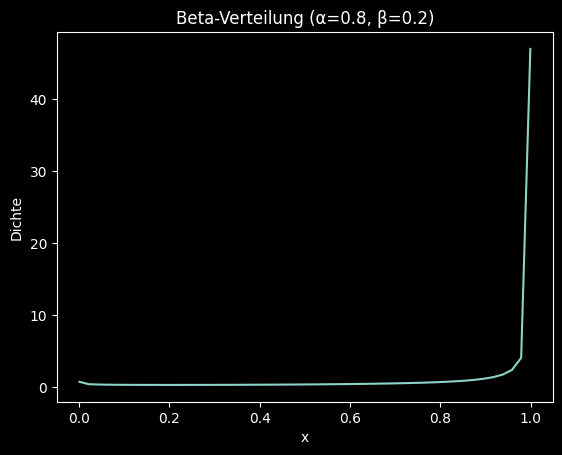

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Parameter
alpha = 0.8
beta_param = 0.2

# x-Werte (nicht genau 0 oder 1 wegen Singularitäten!)
x = np.linspace(0.001, 0.999, 50)

# Dichte
y = beta.pdf(x, alpha, beta_param)

# Plot
plt.plot(x, y)
plt.title(f"Beta-Verteilung (α={alpha}, β={beta_param})")
plt.xlabel("x")
plt.ylabel("Dichte")
plt.show()

In [8]:
import numpy as np
import subjective_logic as sl
import matplotlib.pyplot as plt

from termcolor import colored

# measurement used for update
update_vec = np.array([0.6,0.4])
# initial alphas of Dirichlet distribution prior to the update
alphas = np.array([1.5,1.5])

dist = sl.DirichletDistribution(alphas)
dist_verify = dist.copy()
mixture = [(1,sl.DirichletDistribution(alphas))]

updated_dist = dist.copy()
zero_update = np.zeros(update_vec.shape)

############################
# begin update

# cbf
dist_verify.evidences += update_vec
# moment matching
updated_dist.moment_matching_update_(update_vec)
#mixture
new_mixture = []
# valid for a single update
for (factor, distr) in mixture:
    for idx, value in enumerate(update_vec):
        inc = zero_update.copy()
        inc[idx] = 1
        new_mixture.append((factor * value, sl.DirichletDistribution(distr.alphas() + inc)))
mixture = new_mixture

############################
# end update

# calc mean and variance of mixture
mixture_mean = zero_update.copy()
mixture_var = zero_update.copy()
for factor, distr in mixture:
    mixture_mean += factor * distr.mean()
    mixture_var += factor * distr.variances() + factor * distr.mean()*distr.mean()
mixture_var -= mixture_mean * mixture_mean

print(f"mean: {mixture_mean} | {colored('mixture', 'yellow')}")
print(f"mean: {updated_dist.mean()} | {colored('moment matching update', 'green')}")
print(f"mean: {dist_verify.mean()} | {colored('cbf','red')}")
print()
print(f"var: {mixture_var} | {colored('mixture', 'yellow')}")
print(f"var: {updated_dist.variances()} | {colored('moment matching update','green')}")
print(f"var: {dist_verify.variances()} | {colored('cbf','red')}")
print()
print(f"alphas {dist.alphas()} | {colored('before update','blue')}")
print(f"{colored('mixture', 'yellow')} components:")
for factor, distr in mixture:
    print(f"\tfactor: {factor}, alphas: {distr.alphas()}")
print(f"alphas: {updated_dist.alphas()} | {colored('moment matching update','green')}")
print(f"alphas: {dist_verify.alphas()} | {colored('cbf','red')}")


# sample distrs for plotting
x_samples = np.linspace(0,1,100)
orig = np.array(list(map(dist.evaluate, x_samples)))
update_mixture = np.zeros(orig.shape)
for factor, distr in mixture:
    update_mixture += factor * np.array(list(map(distr.evaluate, x_samples)))
update_mm = list(map(updated_dist.evaluate, x_samples))
update_verify = list(map(dist_verify.evaluate, x_samples))

# plot distributions
plt.plot(orig, color='b', label='before update')
plt.plot(update_mixture, color='orange', label='mixture')
plt.plot(update_mm, color='green', label='moment matching')
plt.plot(update_verify, color='red', label='cbf')
plt.legend()
plt.show()


mean: [0.525 0.475] | mixture
mean: [ 0.525000 0.475000] | moment matching update
mean: [ 0.525000 0.475000] | cbf

var: [0.061875 0.061875] | mixture
var: [ 0.061875 0.061875] | moment matching update
var: [ 0.049875 0.049875] | cbf

alphas [ 1.500000 1.500000] | before update
mixture components:
	factor: 0.6, alphas: [ 2.500000 1.500000]
	factor: 0.4, alphas: [ 1.500000 2.500000]
alphas: [ 1.590909 1.439394] | moment matching update
alphas: [ 2.100000 1.900000] | cbf


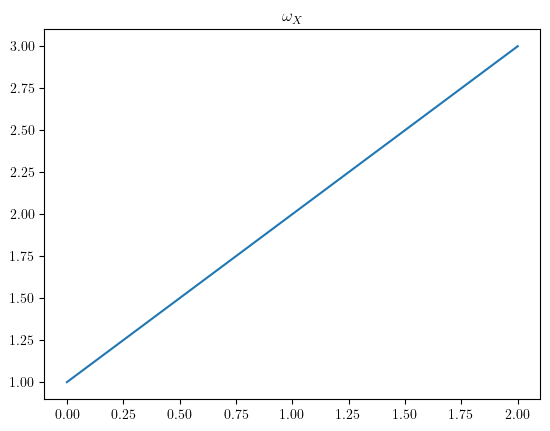

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["text.usetex"] = True

plt.title(r"$\omega_X$")

plt.plot([1,2,3])
plt.show()